In [1]:
import warnings
warnings.filterwarnings('ignore') 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from PIL import Image
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import torch.optim as optim
import torch.nn.functional as F
import colorama
from colorama import Fore, Style

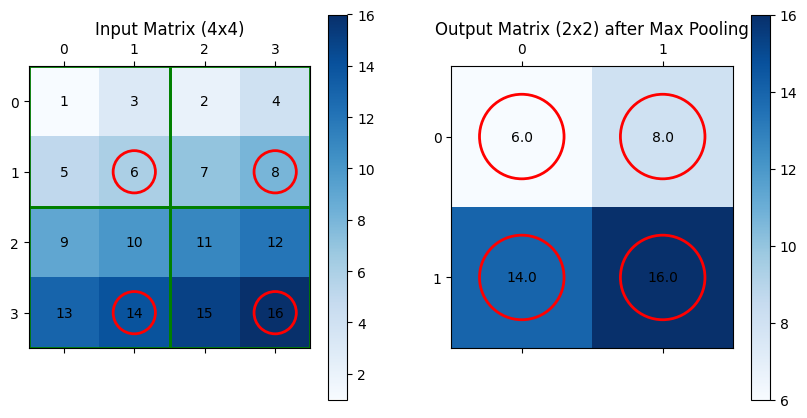

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Define the input 4x4 matrix
input_matrix = np.array([[1, 3, 2, 4],
                         [5, 6, 7, 8],
                         [9, 10, 11, 12],
                         [13, 14, 15, 16]])

# Define the pooling function
def max_pooling(input_matrix, pool_size=2, stride=2):
    # Get the output dimensions
    output_height = (input_matrix.shape[0] - pool_size) // stride + 1
    output_width = (input_matrix.shape[1] - pool_size) // stride + 1
    
    # Initialize the output matrix
    output_matrix = np.zeros((output_height, output_width))
    
    # Apply max pooling
    for i in range(output_height):
        for j in range(output_width):
            # Define the window (2x2 region)
            window = input_matrix[i*stride:i*stride+pool_size, j*stride:j*stride+pool_size]
            # Assign the max value to the output matrix
            output_matrix[i, j] = np.max(window)
    
    return output_matrix

# Apply max pooling to the input matrix
output_matrix = max_pooling(input_matrix)

# Plotting the input matrix
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Input Matrix
cax1 = ax[0].matshow(input_matrix, cmap='Blues')
for (i, j), val in np.ndenumerate(input_matrix):
    ax[0].text(j, i, f'{val}', ha='center', va='center', color='black')

# Highlight the 2x2 grids and circle the max value in each grid
for i in range(0, input_matrix.shape[0], 2):  # iterate in steps of 2
    for j in range(0, input_matrix.shape[1], 2):
        # Highlight the 2x2 grid with a rectangle
        rect = plt.Rectangle((j - 0.5, i - 0.5), 2, 2, linewidth=2, edgecolor='green', facecolor='none')
        ax[0].add_patch(rect)
        
        # Find the maximum value in the 2x2 region
        window = input_matrix[i:i+2, j:j+2]
        max_val = np.max(window)
        max_pos = np.unravel_index(np.argmax(window), window.shape)
        
        # Circle the max value in the region
        ax[0].add_patch(plt.Circle((j + max_pos[1], i + max_pos[0]), 0.3, color='red', fill=False, linewidth=2))

ax[0].set_title('Input Matrix (4x4)')
fig.colorbar(cax1, ax=ax[0])

# Output Matrix
cax2 = ax[1].matshow(output_matrix, cmap='Blues')
for (i, j), val in np.ndenumerate(output_matrix):
    ax[1].text(j, i, f'{val:.1f}', ha='center', va='center', color='black')

# Circle around max values in each 2x2 region of output
for i in range(output_matrix.shape[0]):
    for j in range(output_matrix.shape[1]):
        max_val = output_matrix[i, j]
        ax[1].add_patch(plt.Circle((j, i), 0.3, color='red', fill=False, linewidth=2))

ax[1].set_title('Output Matrix (2x2) after Max Pooling')
fig.colorbar(cax2, ax=ax[1])

plt.show()


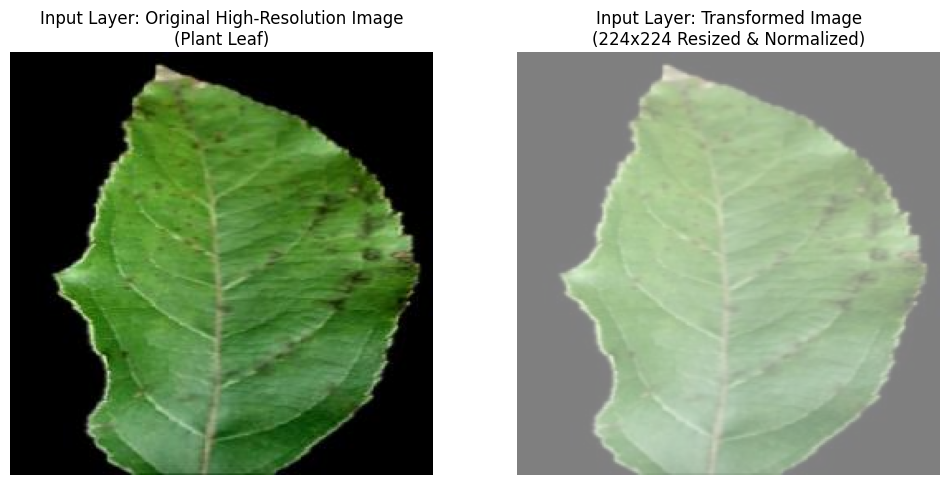

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms

# Load your image (replace with actual image path)
img = Image.open('../apple_scab.jpg')  # Replace with your actual image path

# Original image (no transformation applied)
original_img = np.array(img)

# Define the transformation (resize and normalize)
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize image to 224x224
    transforms.ToTensor(),          # Convert to tensor
    # transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalize the image
])

# Apply the transformation
transformed_img = transform(img)

# Plotting the original image and transformed image (for neural network input)
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Left: Original Image (before transformation)
ax[0].imshow(original_img)
ax[0].axis('off')  # Turn off axis
ax[0].set_title("Input Layer: Original High-Resolution Image\n(Plant Leaf)")

# Right: Transformed Image (after resize and normalization)
# Convert transformed tensor back to NumPy array for visualization
transformed_img = transformed_img.permute(1, 2, 0).numpy()  # Convert from CxHxW to HxWxC
transformed_img = (transformed_img * 0.5) + 0.5  # Unnormalize the image for visualization

ax[1].imshow(transformed_img)
ax[1].axis('off')  # Turn off axis
ax[1].set_title("Input Layer: Transformed Image\n(224x224 Resized & Normalized)")

plt.show()


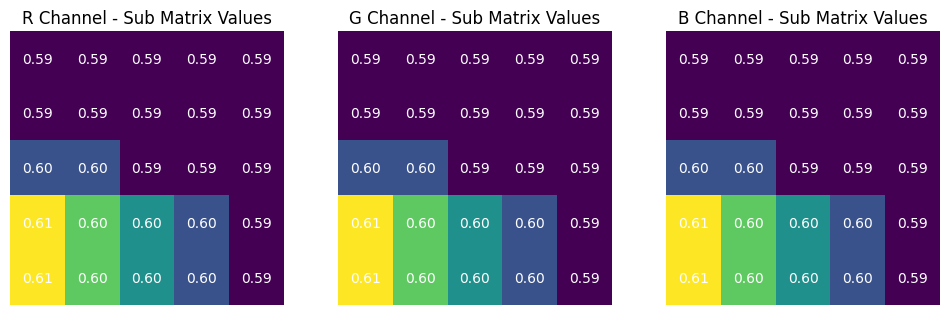


Tensor Shape (C, H, W): torch.Size([3, 224, 224])


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms
import torch

# Load your image (replace with actual image path)
img = Image.open('../data/Leaf/raw/processed_train/Apple___Apple_scab/augmented_0a769a71-052a-4f19-a4d8-b0f0cb75541c___FREC_Scab 3165.jpg')

# Convert image to RGB if it is not already
img = img.convert('RGB')

# Define the transformation (resize and normalize)
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize image to 224x224
    transforms.ToTensor(),          # Convert to tensor
    # transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalize the image
])

# Apply the transformation (resize and normalize)
transformed_img = transform(img)

# Choose the section of the matrix to display (e.g., 5x5)
sub_matrix_size = 5
start_idx = 0  # Start from the top-left corner (you can change this to any valid index)

# Plotting the numerical matrix values for each channel (R, G, B)
fig, ax = plt.subplots(1, 3, figsize=(12, 6))

# Plot each channel (R, G, B) as a matrix with numerical values
for i, channel in enumerate(['R', 'G', 'B']):
    matrix = transformed_img[i].numpy()  # Convert to numpy for easy viewing
    sub_matrix = matrix[start_idx:start_idx+sub_matrix_size, start_idx:start_idx+sub_matrix_size]  # Extract subsection
    
    ax[i].imshow(sub_matrix, cmap='viridis')  # Show the sub-matrix as an image
    ax[i].axis('off')  # Turn off axis
    ax[i].set_title(f"{channel} Channel - Sub Matrix Values")

    # Add numerical values to each pixel in the sub-matrix
    for (j, k), val in np.ndenumerate(sub_matrix):
        ax[i].text(k, j, f'{val:.2f}', ha='center', va='center', color='white', fontsize=10)

plt.show()

# Optionally, print the shape of the tensor
print("\nTensor Shape (C, H, W):", transformed_img.shape)


In [5]:
# Example of calculating mean and std for a custom dataset
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

# Assuming you have a custom dataset in the 'data/' folder
dataset = ImageFolder('../data/Leaf/raw/processed_train', transform=transforms.ToTensor())
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Calculate mean and std
mean = 0.0
std = 0.0
total_images = 0

for images, _ in dataloader:
    batch_samples = images.size(0)  # Number of images in the batch
    images = images.view(batch_samples, images.size(1), -1)  # Flatten the images
    mean += images.mean(2).sum(0)  # Calculate mean across each channel
    std += images.std(2).sum(0)  # Calculate std across each channel
    total_images += batch_samples

mean /= total_images
std /= total_images

print('Mean:', mean)
print('Std:', std)


Mean: tensor([0.5284, 0.5284, 0.5284])
Std: tensor([0.1765, 0.1765, 0.1765])


In [32]:
# def load_images_from_folder(folder, img_size=(128, 128), dtype = 'float32'):
#     images = []
#     labels = []
#     for label in os.listdir(folder):
#         label_folder = os.path.join(folder, label)
#         if os.path.isdir(label_folder):
#             for filename in os.listdir(label_folder):
#                 img_path = os.path.join(label_folder, filename)
#                 image = cv2.imread(img_path)
#                 if image is not None:
#                     image = cv2.resize(image, img_size)
#                     # image = image / 255.0  # Normalize
#                     images.append(image)
#                     labels.append(label)
#     return np.array(images), np.array(labels)


In [ ]:
dir = "../data/leaf/disease"

In [9]:
dir = "../data/leaf"
train_dir = dir + "/disease"

disease_class = os.listdir(train_dir)

In [3]:
print(str(disease_class))
print("\nTotal Classes:", len(disease_class))

['Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___healthy', 'Corn_(maize)___Northern_Leaf_Blight', 'rice_bacterial_blight', 'rice_blast', 'rice_brown_spot', 'rice_leaf_scaled', 'rice_leaf_smut', 'rice_shath_blight', 'rice_tungro']

Total Classes: 11


In [4]:
import os
import shutil

# Define source and destination directories
source_dir = "../data/leaf/raw/color"  # Change this to your dataset folder
destination_dir = "../data/leaf/raw/selected"  # Change this to your destination folder

# Define classes to keep
selected_classes = [
    "Apple___Apple_scab", "Apple___Black_rot", "Apple___Cedar_apple_rust", "Apple___healthy",
    "Tomato___Bacterial_spot", "Tomato___Early_blight", "Tomato___healthy", "Tomato___Late_blight",
    "Tomato___Leaf_Mold", "Tomato___Septoria_leaf_spot", "Tomato___Spider_mites Two-spotted_spider_mite",
    "Tomato___Target_Spot", "Tomato___Tomato_mosaic_virus", "Tomato___Tomato_Yellow_Leaf_Curl_Virus",
    "Grape___Black_rot", "Grape___Esca_(Black_Measles)", "Grape___healthy", "Grape___Leaf_blight_(Isariopsis_Leaf_Spot)",
    "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot", "Corn_(maize)___Common_rust_", "Corn_(maize)___healthy", "Corn_(maize)___Northern_Leaf_Blight"
]

# Create directories for selected classes
for class_name in selected_classes:
    class_path = os.path.join(destination_dir, class_name)
    os.makedirs(class_path, exist_ok=True)

# Copy files from source to destination
for class_name in selected_classes:
    source_class_path = os.path.join(source_dir, class_name)
    destination_class_path = os.path.join(destination_dir, class_name)
    
    if os.path.exists(source_class_path):
        for file_name in os.listdir(source_class_path):
            source_file = os.path.join(source_class_path, file_name)
            destination_file = os.path.join(destination_class_path, file_name)
            shutil.copy(source_file, destination_file)

print("Filtered dataset created successfully.")


Filtered dataset created successfully.



Total Number of Images in Directory: 7685


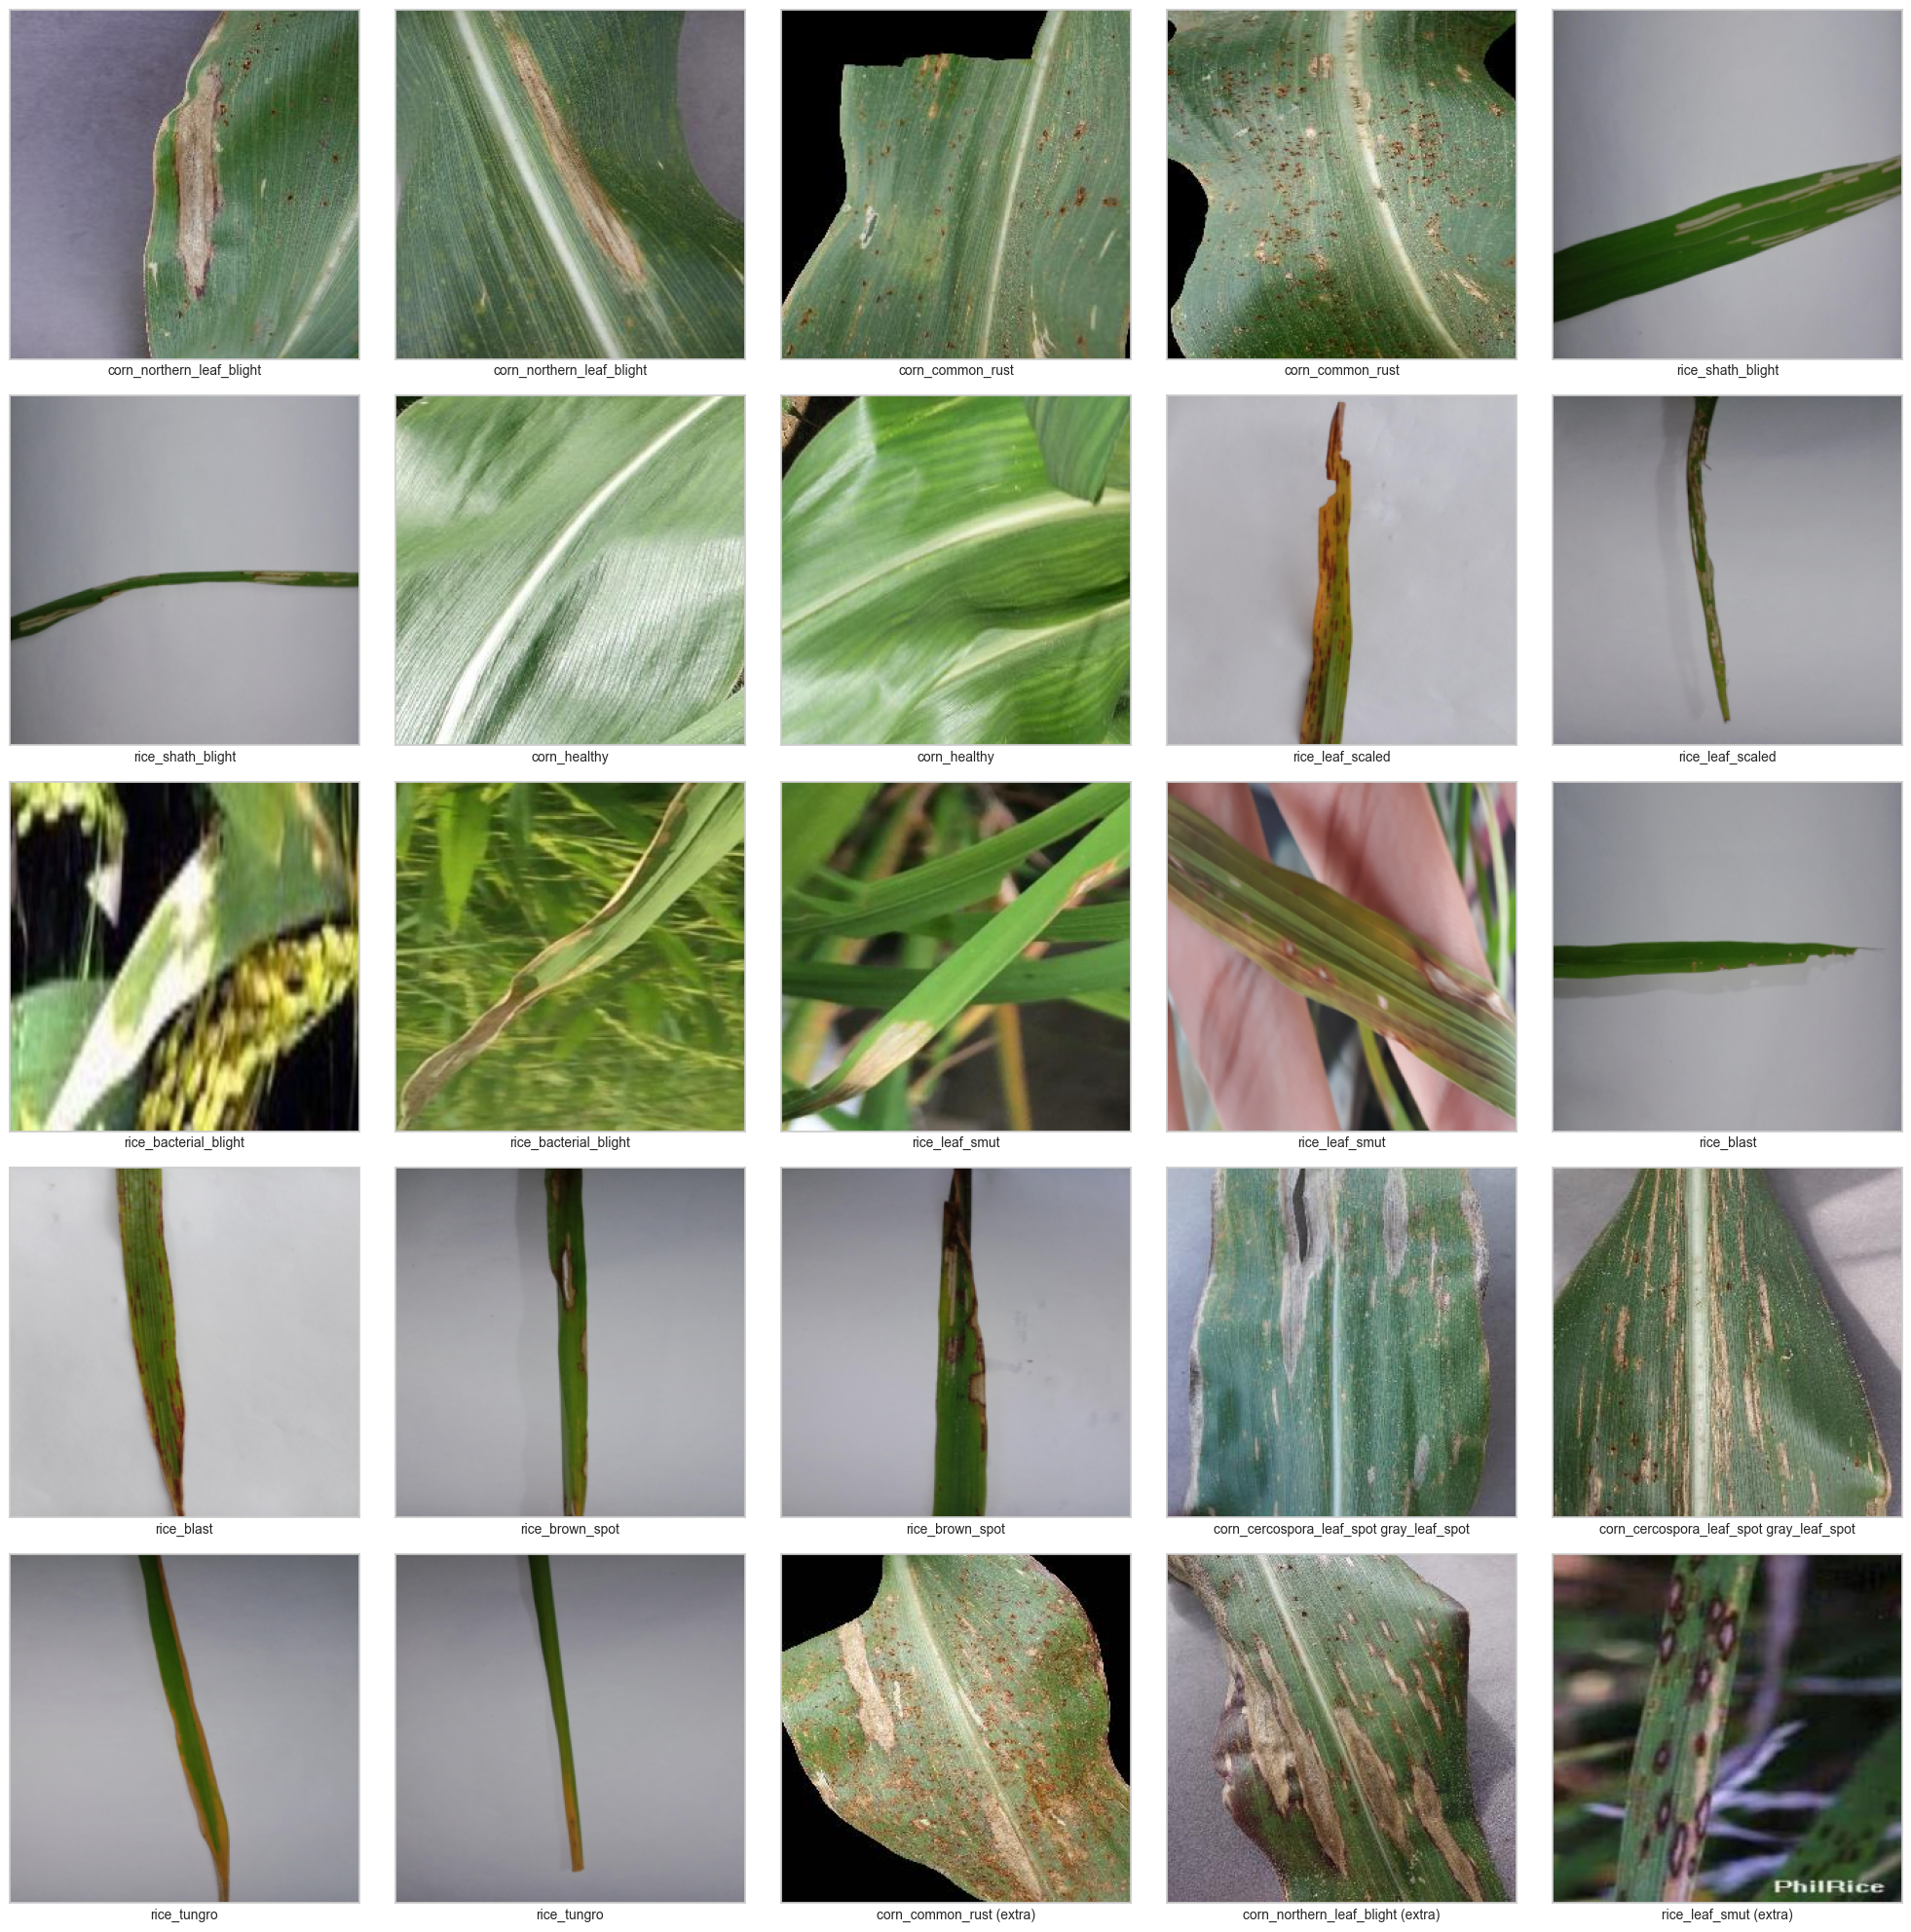

In [19]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms

random.shuffle(disease_class)  # Optional: shuffle class order

transform = transforms.Compose([
    transforms.Resize((256, 256)),
])

images_per_class = 2
selected_classes = disease_class[:11]  # 11 classes → 22 images
extra_images_needed = 3
cnt = 1

plt.figure(figsize=(20, 20))
total_images = 0

# --- 1. First 22 images: 2 per class from 11 classes ---
for class_name in selected_classes:
    class_path = os.path.join(train_dir, class_name)
    image_files = os.listdir(class_path)
    total_images += len(image_files)

    random.shuffle(image_files)

    for i in range(min(images_per_class, len(image_files))):
        img_path = os.path.join(class_path, image_files[i])
        img = Image.open(img_path).convert('RGB')
        img_transformed = transform(img)

        plt.subplot(5, 5, cnt)
        plt.imshow(img_transformed)
        plt.xlabel(class_name, fontsize=10)
        plt.xticks([])
        plt.yticks([])
        cnt += 1

# --- 2. Add 3 random images from any class ---
all_images = []
for class_name in disease_class:
    class_path = os.path.join(train_dir, class_name)
    for fname in os.listdir(class_path):
        all_images.append((class_name, os.path.join(class_path, fname)))

random.shuffle(all_images)
extra_images = all_images[:extra_images_needed]

for class_name, img_path in extra_images:
    img = Image.open(img_path).convert('RGB')
    img_transformed = transform(img)

    plt.subplot(5, 5, cnt)
    plt.imshow(img_transformed)
    plt.xlabel(class_name + ' (extra)', fontsize=10)
    plt.xticks([])
    plt.yticks([])
    cnt += 1

print("\nTotal Number of Images in Directory:", total_images)
plt.tight_layout()
plt.show()



In [22]:
import os
from collections import Counter

# Replace with the path to your dataset
# dataset_path = "path_to_your_dataset"

# Get all class folders
class_counts = {}

for class_name in os.listdir(train_dir ):
    class_folder = os.path.join(train_dir , class_name)
    if os.path.isdir(class_folder):
        num_images = len([
            file for file in os.listdir(class_folder)
            if file.lower().endswith(('.png', '.jpg', '.jpeg'))
        ])
        class_counts[class_name] = num_images

# Print the results
for class_name, count in sorted(class_counts.items()):
    print(f"{class_name}: {count} images")


corn_cercospora_leaf_spot gray_leaf_spot: 513 images
corn_common_rust: 1192 images
corn_healthy: 1162 images
corn_northern_leaf_blight: 985 images
rice_bacterial_blight: 1604 images
rice_blast: 198 images
rice_brown_spot: 90 images
rice_leaf_scaled: 143 images
rice_leaf_smut: 1460 images
rice_shath_blight: 219 images
rice_tungro: 119 images


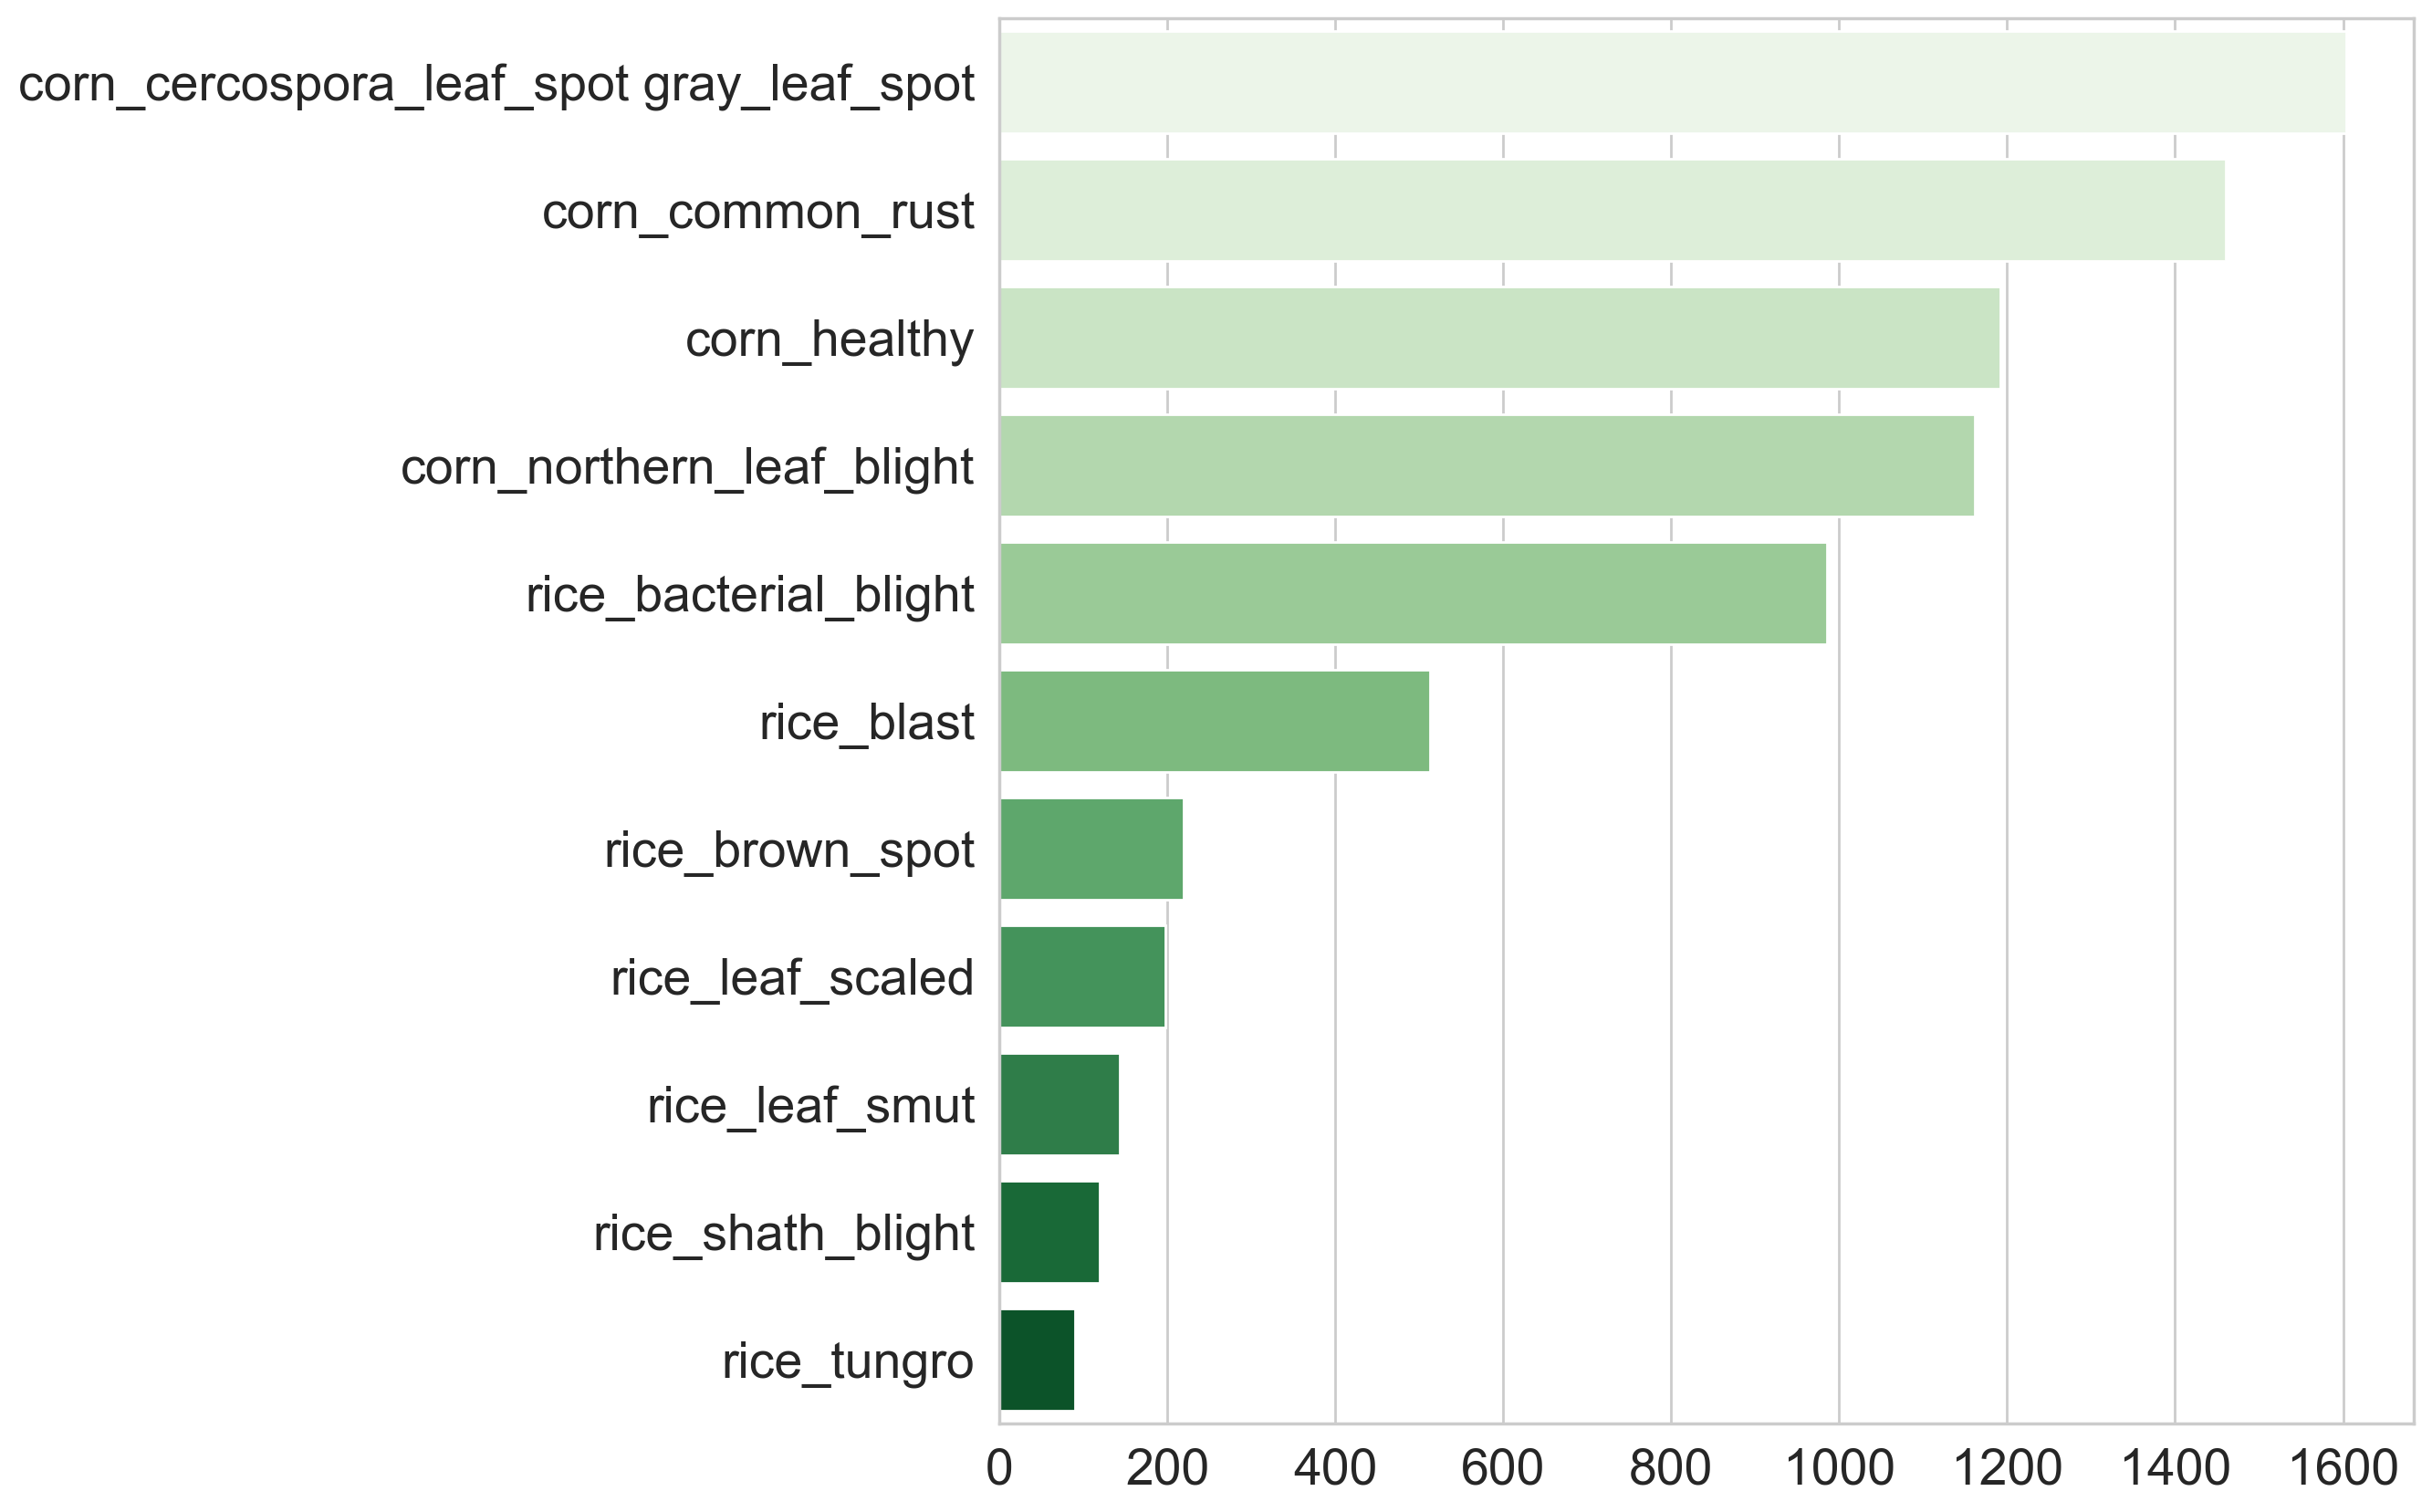

In [12]:
plant_names = []
Len = []
for i in disease_class:
    plant_names.append(i)
    imgs_path = os.listdir(train_dir + "/" + i)
    Len.append(len(imgs_path))

Len.sort(reverse=True)

sns.set(style="whitegrid", color_codes=True)
plt.figure(figsize=(10,10),dpi=200)
ax = sns.barplot(x= Len, y= plant_names, palette="Greens")
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()

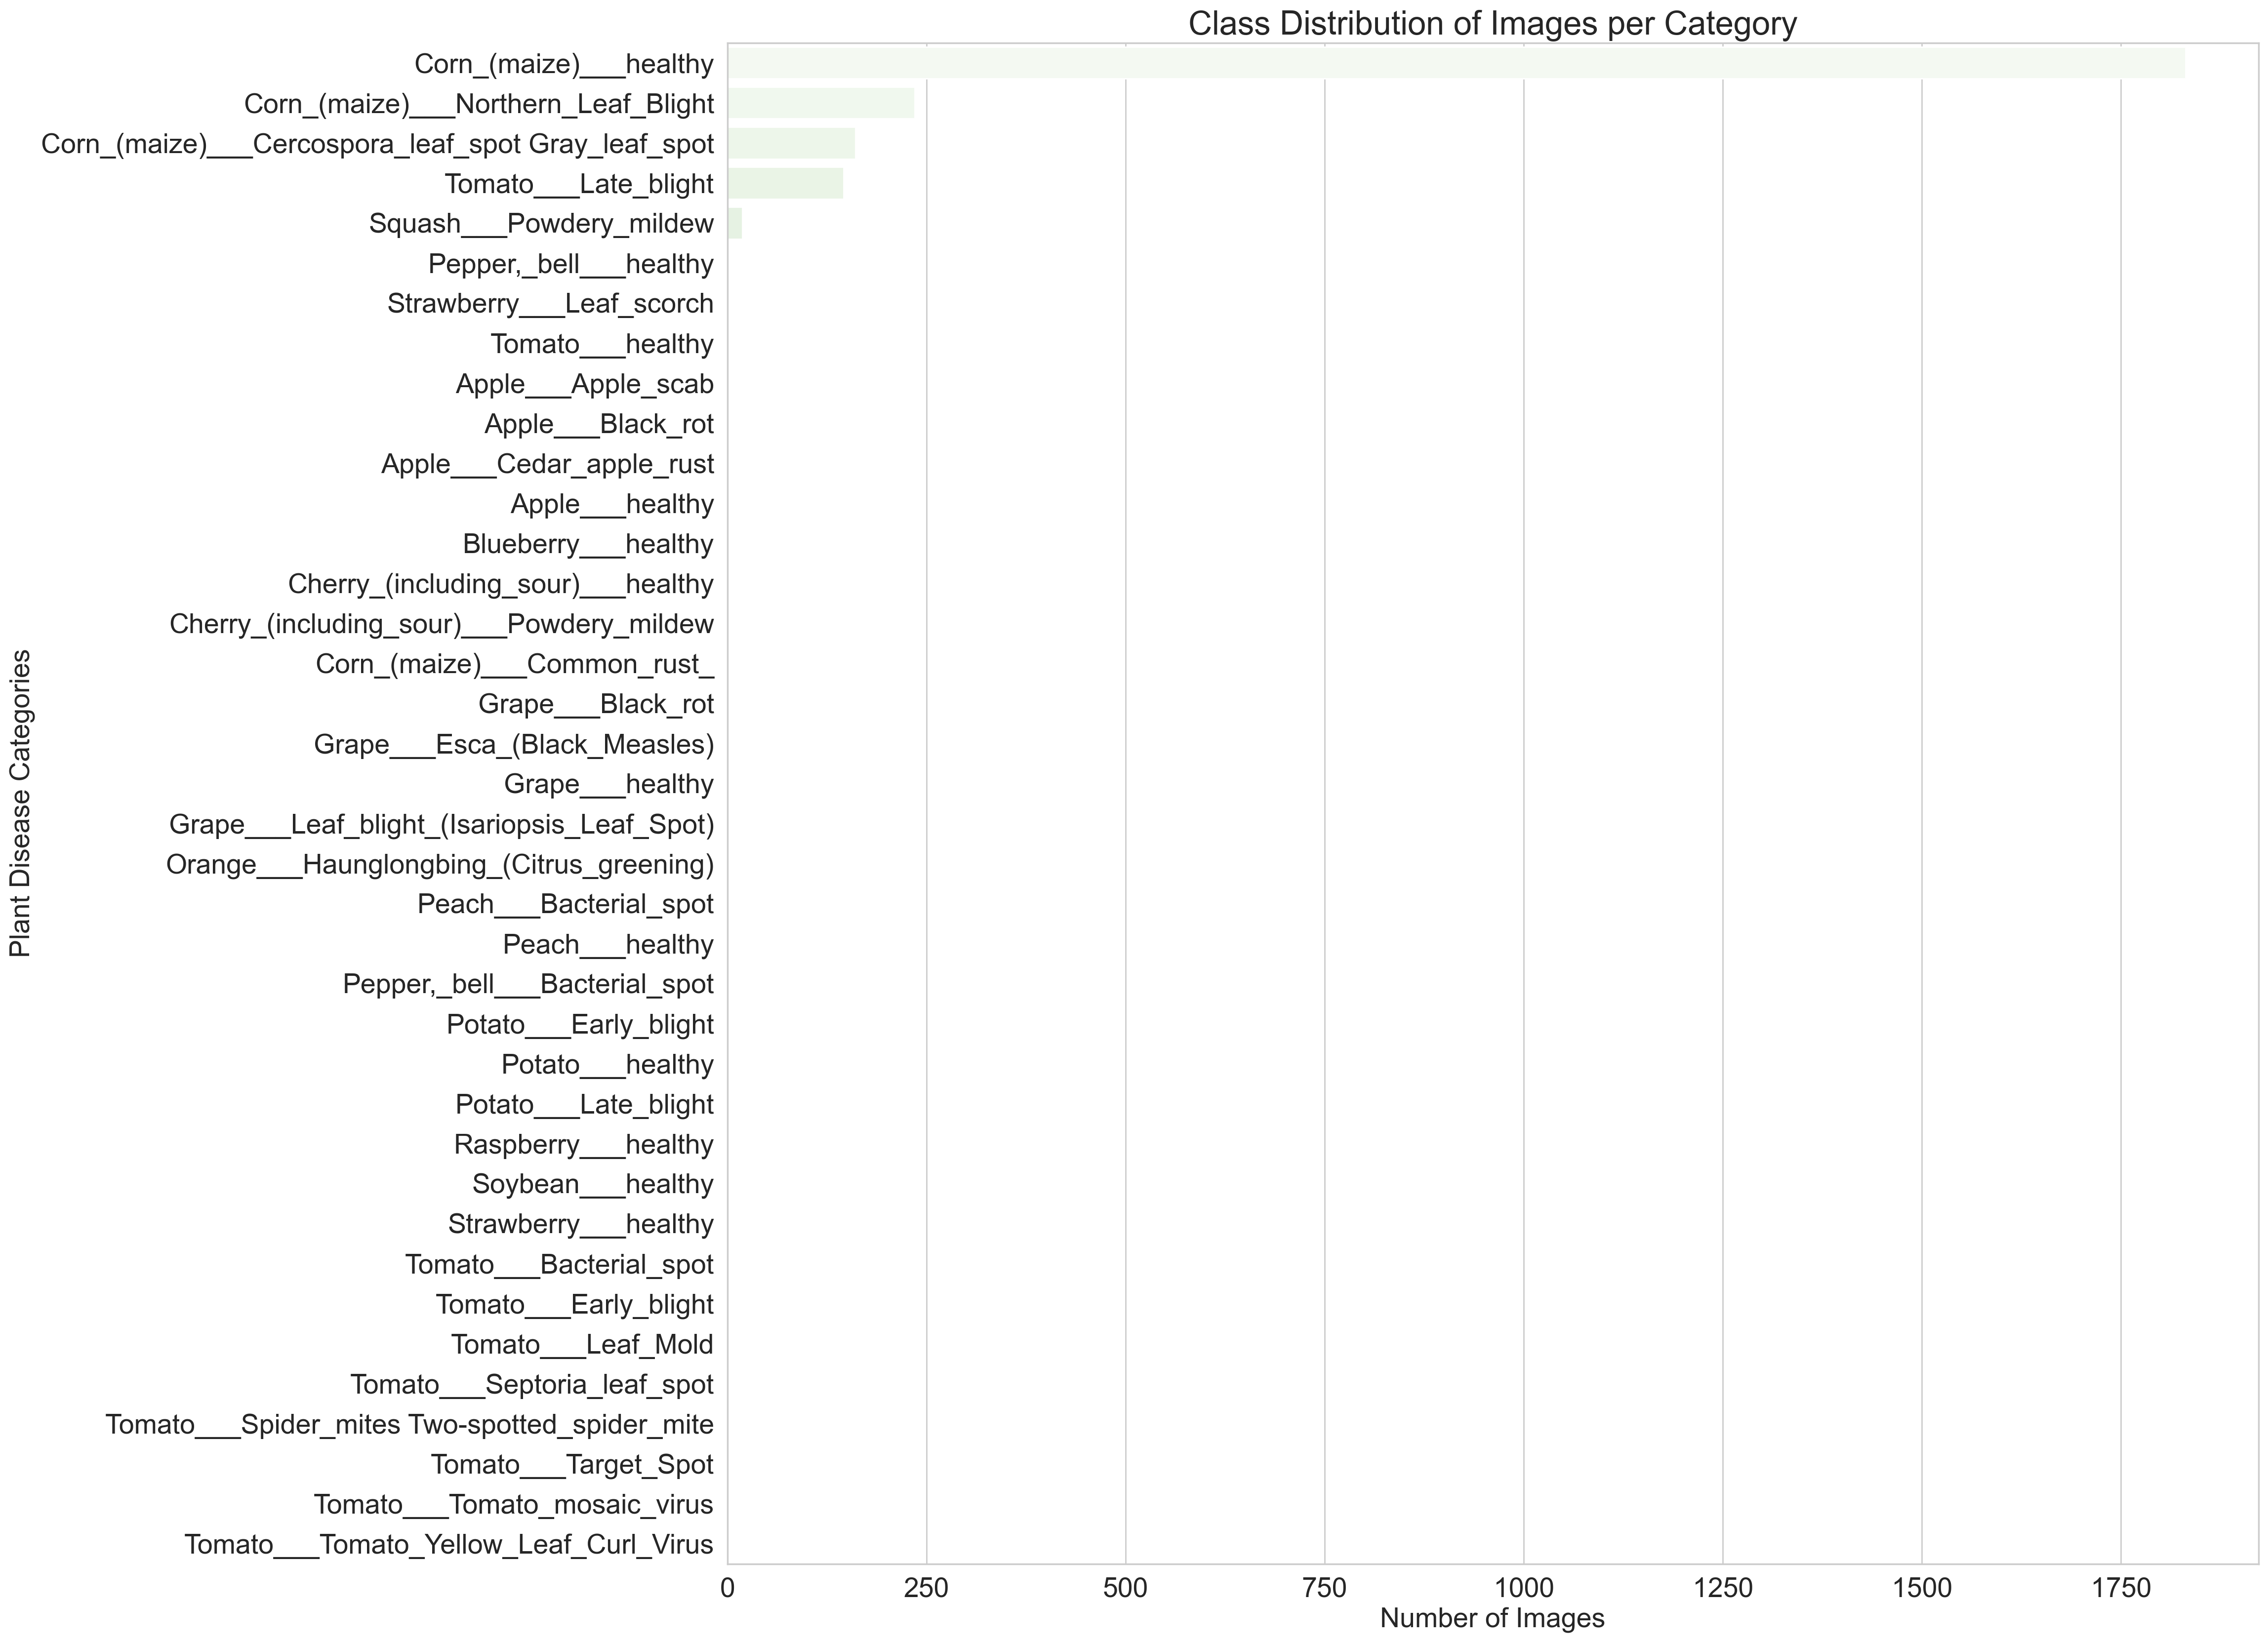

In [38]:

# List all subfolders (disease classes)
disease_classes = os.listdir(train_dir)

# Create lists to store plant names and their corresponding image counts
plant_names = []
Len = []

# Loop through each disease class and count the images
for disease_class in disease_classes:
    class_folder = os.path.join(train_dir, disease_class)
    
    if os.path.isdir(class_folder):  # Ensure it's a directory
        image_files = os.listdir(class_folder)
        plant_names.append(disease_class)
        Len.append(len([f for f in image_files if f.endswith(('png', 'jpg', 'jpeg'))]))

# Sort both plant_names and Len based on Len (image counts)
sorted_plant_names, sorted_len = zip(*sorted(zip(plant_names, Len), key=lambda x: x[1], reverse=True))

# Plot the results
sns.set(style="whitegrid", color_codes=True)
plt.figure(figsize=(20, 20), dpi=200)
ax = sns.barplot(x=sorted_len, y=sorted_plant_names, palette="Greens")
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.title("Class Distribution of Images per Category", fontsize=24)
plt.xlabel("Number of Images", fontsize=20)
plt.ylabel("Plant Disease Categories", fontsize=20)
plt.show()


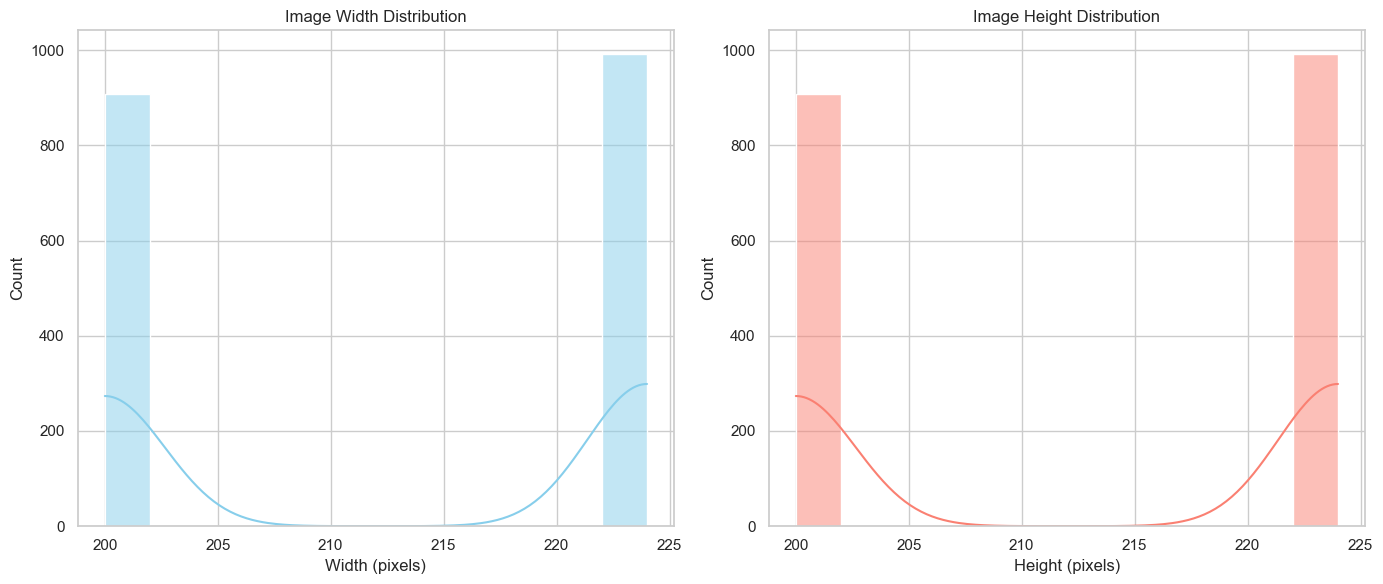

In [39]:
import os
import cv2
import seaborn as sns
import matplotlib.pyplot as plt

# Dataset directory path
dataset_path = "../data/Leaf/augmented_grey_train"

# Lists to store image dimensions
widths = []
heights = []

# Read images and record their dimensions
for class_folder in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_folder)

    # Skip non-directory files
    if not os.path.isdir(class_path):
        continue

    # Process each image in the class folder
    for image_file in os.listdir(class_path):
        if image_file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_path = os.path.join(class_path, image_file)
            image = cv2.imread(image_path)

            # Skip invalid images
            if image is None:
                continue

            # Get image dimensions (height, width)
            h, w = image.shape[:2]
            heights.append(h)
            widths.append(w)

# Plot Image Size Distributions
plt.figure(figsize=(14, 6))

# Width Distribution Plot
plt.subplot(1, 2, 1)
sns.histplot(widths, kde=True, color="skyblue")
plt.title("Image Width Distribution")
plt.xlabel("Width (pixels)")

# Height Distribution Plot
plt.subplot(1, 2, 2)
sns.histplot(heights, kde=True, color="salmon")
plt.title("Image Height Distribution")
plt.xlabel("Height (pixels)")

plt.tight_layout()
plt.show()


In [40]:
train = ImageFolder(train_dir, transform=transforms.ToTensor())
valid = ImageFolder(valid_dir, transform=transforms.ToTensor()) 

In [41]:
train

Dataset ImageFolder
    Number of datapoints: 70243
    Root location: ../data/leaf/train
    StandardTransform
Transform: ToTensor()

In [42]:
train[0]

(tensor([[[0.6549, 0.6510, 0.6471,  ..., 0.7255, 0.7176, 0.7098],
          [0.6667, 0.6627, 0.6588,  ..., 0.7294, 0.7216, 0.7176],
          [0.6667, 0.6627, 0.6588,  ..., 0.7373, 0.7294, 0.7255],
          ...,
          [0.3922, 0.4000, 0.4078,  ..., 0.4941, 0.4941, 0.4941],
          [0.3961, 0.4000, 0.4039,  ..., 0.4784, 0.4824, 0.4824],
          [0.4078, 0.4039, 0.4000,  ..., 0.4745, 0.4784, 0.4824]],
 
         [[0.6392, 0.6353, 0.6314,  ..., 0.7137, 0.7059, 0.6980],
          [0.6510, 0.6471, 0.6431,  ..., 0.7176, 0.7098, 0.7059],
          [0.6510, 0.6471, 0.6431,  ..., 0.7255, 0.7176, 0.7137],
          ...,
          [0.3529, 0.3608, 0.3686,  ..., 0.4314, 0.4314, 0.4314],
          [0.3569, 0.3608, 0.3647,  ..., 0.4157, 0.4196, 0.4196],
          [0.3686, 0.3647, 0.3608,  ..., 0.4118, 0.4157, 0.4196]],
 
         [[0.7686, 0.7647, 0.7608,  ..., 0.8275, 0.8196, 0.8118],
          [0.7804, 0.7765, 0.7725,  ..., 0.8314, 0.8235, 0.8196],
          [0.7804, 0.7765, 0.7725,  ...,

In [43]:
img, label = train[0]
print(img.shape, label)

torch.Size([3, 256, 256]) 0



Label :Apple___Apple_scab(0)

Label :Apple___Black_rot(1)

Label :Apple___Cedar_apple_rust(2)

Label :Blueberry___healthy(4)

Label :Cherry_(including_sour)___healthy(6)

Label :Corn_(maize)___Common_rust_(8)

Label :Tomato___Septoria_leaf_spot(32)

Label :Tomato___healthy(37)


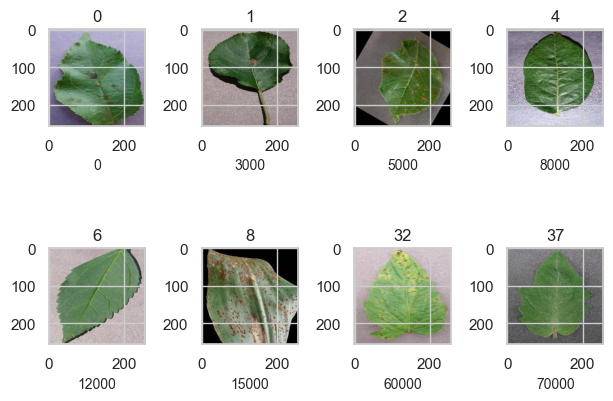

In [44]:
def show_image(image, label):
    print("Label :" + train.classes[label] + "(" + str(label) + ")")
    plt.imshow(image.permute(1, 2, 0))
    
    
image_list = [0, 3000, 5000, 8000, 12000, 15000, 60000, 70000]
batch_size = 32
chs = 0
for img in image_list:
    chs += 1
    plt.subplot(2,4,chs)
    print(Fore.GREEN)
    plt.tight_layout()
    plt.xlabel(img,fontsize=10)
    plt.title(train[img][1])
    show_image(*train[img])

In [45]:
# DataLoaders for training and validation
train_dataloader = DataLoader(train, batch_size, shuffle=True, num_workers=2, pin_memory=True)
valid_dataloader = DataLoader(valid, batch_size, num_workers=2, pin_memory=True)

In [46]:
# for moving data into GPU (if available)
def get_default_device():
    """Pick GPU if available, else CPU"""
    if torch.cuda.is_available:
        return torch.device("cuda")
    else:
        return torch.device("cpu")

In [47]:
# for moving data to device (CPU or GPU)
def to_device(data, device):
    """Move tensor(s) to chosen device"""
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

In [48]:
# for loading in the device (GPU if available else CPU)
class DeviceDataLoader():
    """Wrap a dataloader to move data to a device"""
    def __init__(self, dataloader, device):
        self.dataloader = dataloader
        self.device = device
        
    def __iter__(self):
        """Yield a batch of data after moving it to device"""
        for b in self.dataloader:
            yield to_device(b, self.device)
        
    def __len__(self):
        """Number of batches"""
        return len(self.dataloader)

In [49]:
# device = get_default_device()
# device

In [50]:
# # Set device (CUDA if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device




device(type='cuda')

In [51]:
# Moving data into GPU, WrappedDataLoader
train_dataloader = DeviceDataLoader(train_dataloader, device)
valid_dataloader = DeviceDataLoader(valid_dataloader, device)

In [52]:
# for calculating the accuracy
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))

In [53]:
class ImageClassificationBase(nn.Module):
    
    def training_step(self, batch):
        images, labels = batch 
        out = self(images)                  # Generate predictions
        loss = F.cross_entropy(out, labels) # Calculate loss
        return loss
    
    def validation_step(self, batch):
        images, labels = batch 
        out = self(images)                    # Generate predictions
        loss = F.cross_entropy(out, labels)   # Calculate loss
        acc = accuracy(out, labels)           # Calculate accuracy
        return {'val_loss': loss.detach(), 'val_acc': acc}
        
    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()   # Combine losses
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()      # Combine accuracies
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}
    
    def epoch_end(self, epoch, result):
        print("Epoch [{}], train_loss: {:.4f}, val_loss: {:.4f}, val_acc: {:.4f}".format(
            epoch, result['train_loss'], result['val_loss'], result['val_acc']))

In [54]:
# convolution block with BatchNormalization
def ConvBlock(in_channels, out_channels, pool=False):
    layers = [nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
             nn.BatchNorm2d(out_channels),
             nn.ReLU(inplace=True)]
    if pool:
        layers.append(nn.MaxPool2d(4))
    return nn.Sequential(*layers)

In [55]:
# resnet architecture 
class CNN_NeuralNet(ImageClassificationBase):
    def __init__(self, in_channels, num_diseases):
        super().__init__()
        
        self.conv1 = ConvBlock(in_channels, 64)
        self.conv2 = ConvBlock(64, 128, pool=True) 
        self.res1 = nn.Sequential(ConvBlock(128, 128), ConvBlock(128, 128))
        
        self.conv3 = ConvBlock(128, 256, pool=True) 
        self.conv4 = ConvBlock(256, 512, pool=True)
        #self.conv5 = ConvBlock(256, 256, pool=True)
        #self.conv6 = ConvBlock(256, 512, pool=True)
        #self.conv7 = ConvBlock(512, 512, pool=True)
        
        self.res2 = nn.Sequential(ConvBlock(512, 512), ConvBlock(512, 512))
        self.classifier = nn.Sequential(nn.MaxPool2d(4),
                                       nn.Flatten(),
                                       nn.Linear(512, num_diseases))
        
    def forward(self, x): # x is the loaded batch
        out = self.conv1(x)
        out = self.conv2(out)
        out = self.res1(out) + out
        out = self.conv3(out)
        out = self.conv4(out)
        #out = self.conv5(out)
        #out = self.conv6(out)
        #out = self.conv7(out)
        out = self.res2(out) + out
        out = self.classifier(out)
        return out        

In [56]:
# defining the model and moving it to the GPU
# 3 is number of channels RGB, len(train.classes()) is number of diseases.
model = to_device(CNN_NeuralNet(3, len(train.classes)), device) 
model

CNN_NeuralNet(
  (conv1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (conv2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  )
  (res1): Sequential(
    (0): Sequential(
      (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (1): Sequential(
      (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inpl

In [57]:
import torch
print(torch.cuda.is_available())  # Should return True if CUDA is accessible
print(torch.cuda.device_count())  # Shows number of GPUs available
print(torch.cuda.get_device_name(0)) if torch.cuda.is_available() else print("No CUDA device")


True
1
NVIDIA GeForce GTX 1650


In [58]:
# for training
@torch.no_grad()
def evaluate(model, val_loader):
    model.eval()
    outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)

In [59]:
def fit_OneCycle(epochs, max_lr, model, train_loader, val_loader, weight_decay=0,
                grad_clip=None, opt_func=torch.optim.SGD):
    torch.cuda.empty_cache()
    history = []  #For collecting the results
    
    optimizer = opt_func(model.parameters(), max_lr, weight_decay=weight_decay)
    # scheduler for one cycle learniing rate
    #Sets the learning rate of each parameter group according to the 1cycle learning rate policy. 
    #The 1cycle policy anneals the learning rate from an initial learning rate to some 
    #maximum learning rate and then from that maximum learning rate to some minimum learning rate
    #much lower than the initial learning rate. 
    sched = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr,
                                                epochs=epochs, steps_per_epoch=len(train_loader))
    
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_losses = []
        lrs = []
        for batch in train_loader:
            loss = model.training_step(batch)
            train_losses.append(loss)
            loss.backward()
            
            # gradient clipping
            #Clip the gradients of an iterable of parameters at specified value.
            #All from pytorch documantation.
            if grad_clip: 
                nn.utils.clip_grad_value_(model.parameters(), grad_clip)
                
            optimizer.step()
            optimizer.zero_grad()
            
            # recording and updating learning rates
            lrs.append(get_lr(optimizer))
            sched.step()
             # validation
        
        result = evaluate(model, val_loader)
        result['train_loss'] = torch.stack(train_losses).mean().item()
        result['lrs'] = lrs
        model.epoch_end(epoch, result)
        history.append(result)
        
    return history
    

In [61]:
# %%time
# history = [evaluate(model, valid_dataloader)]
# history

In [29]:
def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group['lr']


In [30]:
num_epoch = 3
lr_rate = 0.01
grad_clip = 0.15
weight_decay = 1e-4

optims = torch.optim.Adam

In [31]:
%%time
history += fit_OneCycle(num_epoch, lr_rate, model, train_dataloader, valid_dataloader, 
                             grad_clip=grad_clip, 
                             weight_decay=weight_decay, 
                             opt_func=optims)

Epoch [0], train_loss: 0.7187, val_loss: 2.4355, val_acc: 0.4787
Epoch [1], train_loss: 0.2610, val_loss: 0.3538, val_acc: 0.8835
Epoch [2], train_loss: 0.0674, val_loss: 0.0261, val_acc: 0.9925
CPU times: total: 1h 32min 31s
Wall time: 14h 58min 18s


In [39]:
import torch

def save_model(model, path='model.pth'):
    """
    Save the model state dictionary to the given path.
    
    Args:
        model: Trained PyTorch model.
        path: Path where the model should be saved.
    """
    torch.save(model.state_dict(), path)
    print(f"Model saved to {path}")


In [51]:
# val_acc = []
# val_loss = []
# train_loss = []

# for i in history:
#     val_acc.append(i['val_acc'])
#     val_loss.append(i['val_loss'])
#     train_loss.append(i.get('train_loss'))

In [48]:
# epoch_count = range(1,7)
# plt.figure(figsize=(10,5), dpi=200)
# plt.plot(epoch_count, train_loss, 'r--', color= 'orangered')
# plt.plot(epoch_count, val_loss, '--bo',color= 'green', linewidth = '2.5', label='line with marker')
# plt.legend(['Training Loss', 'Val Loss'])
# plt.title('Number of epochs & Loss')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.xticks(np.arange(1,7,1))
# plt.show();

In [49]:
# epoch_count = range(1,7)
# plt.figure(figsize=(10,5), dpi=200)
# plt.plot(epoch_count, val_acc, '--bo',color= 'green', linewidth = '2.5', label='line with marker')
# plt.legend(['Val Acc'])
# plt.title('Number of epochs & Acc')
# plt.xlabel('Epoch')
# plt.ylabel('Acc')
# plt.xticks(np.arange(1,7,1))
# plt.show();

In [150]:
test = ImageFolder(test_dir, transform=transforms.ToTensor())
test_images = sorted(os.listdir(test_dir))

# print(train_images)
print(len(test_images))

33


In [151]:
def predict_image(img, model):
    """Converts image to array and return the predicted class
        with highest probability"""
    # Convert to a batch of 1
    xb = to_device(img.unsqueeze(0), device)
    # Get predictions from model
    yb = model(xb)
    # Pick index with highest probability
    _, preds  = torch.max(yb, dim=1)
    # Retrieve the class label

    return train.classes[preds[0].item()]

In [158]:
import os
import torch
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms



# Define image transformation (same as during training)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Load your trained model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Function to predict class name from image
def predict_image(img, model):
    """Predict the class name with the highest probability."""
    img = transform(img).unsqueeze(0).to(device)  # Transform and move to device
    with torch.no_grad():
        output = model(img)
        probabilities = torch.nn.functional.softmax(output[0], dim=0)
        predicted_class = torch.argmax(probabilities).item()
        return predict_class

# Get all images in the test folder
image_paths = [os.path.join(test_images, fname) for fname in os.listdir(test_images) if fname.endswith('.jpg') or fname.endswith('.png')]

# Iterate over all images in the folder
for image_path in image_paths:
    # Load the image
    image = Image.open(image_path).convert('RGB')
    
    # Display the image using matplotlib
    plt.imshow(image)
    plt.show()

    # Get the predicted class name
    predicted_class = predict_image(image, model)

    # If you want to extract class name from filename (e.g., apple_1.jpg), you can do:
    actual_label_name = os.path.basename(image_path).split('_')[0]  # Example: 'apple_1.jpg' -> 'apple'

    # Print the actual class (from filename) and the predicted class
    print(f'Actual Label: {actual_label_name}')
    print(f'Predicted: {predicted_class}')


TypeError: listdir: path should be string, bytes, os.PathLike or None, not list

Label: Cherry_(including_sour)___Powdery_mildew , Predicted: Apple___Cedar_apple_rust


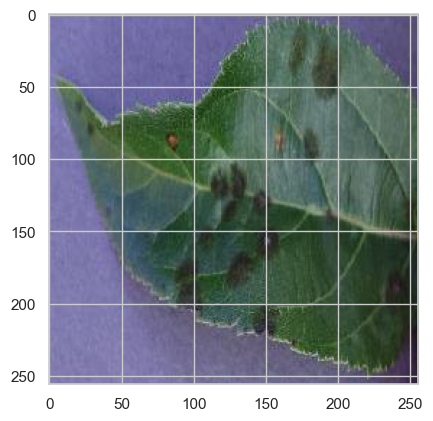

In [149]:
# predicting first image
img, label = test[3]
plt.imshow(img.permute(1, 2, 0))
print('Label:', test_images[5], ', Predicted:', predict_image(img, model))

In [109]:
import torch
import torchvision.transforms as transforms
from PIL import Image

# Load your trained model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
input_tensor = input_tensor.to(device)




# Define image transformations (same as during training)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Load test images
  # Add paths to test images
transform = transforms.Compose([
    transforms.Resize((256, 256)),  # Increase the size
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])
for image_path in image_paths:
    image = Image.open(image_path).convert('RGB')
    input_tensor = transform(image).unsqueeze(0).to(device)  # Move input to the same device as the model

    # Forward pass
    with torch.no_grad():
        output = model(input_tensor)
        probabilities = torch.nn.functional.softmax(output[0], dim=0)
    
        # Get predicted class and confidence score
        predicted_class = torch.argmax(probabilities).item()
        confidence_score = probabilities[predicted_class].item()

    print(f"Image: {image_path}")
    print(f"Predicted Class: {predicted_class}, Confidence Score: {confidence_score:.4f}")


Image: ../data/Leaf/test/AppleCedarRust2.jpg
Predicted Class: 12, Confidence Score: 0.2555


In [105]:
image_paths = ["../data/Leaf/test/AppleCedarRust2.jpg"]

In [98]:
# print(model.device)
print(input_tensor.device)


cpu


In [99]:
print(next(model.parameters()).device)


cuda:0


In [104]:
# getting all predictions (actual label vs predicted)
for i, (img, label) in enumerate(test):
    print(Fore.GREEN)
    print('Label:', test_images[i], ', Predicted:', predict_image(img, model))


Label: AppleCedarRust1.JPG , Predicted: Apple___healthy

Label: AppleCedarRust2.JPG , Predicted: Tomato___Early_blight
